# ABCD with Outliers (ABCD+o)

The original ABCD model forced every vertex to be part of a community, but it was later extended to allow for outliers: vertices that do not belong to any communities. This is accomplished by making outliers have their entire degree in the global background graph.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from Fstar import fstar
from partition_sknetwork import ECG

from abcd_graph import ABCD

Outliers can be added to the ABCD model by passing either a number of vertices or a proportion of the vertices to become outliers.

In [2]:
abcd = ABCD(1000, outliers=10)
sample = abcd.sample()
print(f"Sample has {sample.outliers} outliers.")

abcd = ABCD(1000, outliers=0.1)
sample = abcd.sample()
print(f"Sample has {sample.outliers} outliers.")

Sample has 10 outliers.
Sample has 100 outliers.


Most community detection algorithms do not allow outliers, so detecting outliers is typically not supported by networkx, igraph, or sknetwork. However, there are methods for detecting outliers post-hoc by looking at how strongly each vertex belongs to its community. One such method, the particulars of which are beyond the scope of this notebook, is available in the [ECG algorithm](https://github.com/ftheberge/graph-partition-and-measures) that can be pip installed for networkx, igraph, or sknetwork. We will use the sknetwork version because it is slightly faster.

In [3]:
sparse_adjacency_matrix = sample.to_sparse(matrix=True)
ground_truth_communities = sample.community_array

ecg = ECG(refuse_score=True)
communities = ecg.fit_predict(sparse_adjacency_matrix)
refuse_scores = ecg.refuse_community_  # These scores indicate
# how strongly a vertex is connected to its community, or how
# unlikely it is to be an outlier

How well does this work? A typical problem with outlier detection is that even if we can rank the vertices by how likely we think they are to be an outlier, there's not a good universal way to pick a decision threshold. Instead, let's look at how good the ordering is. We'll use two method, the number of true outliers found so far and how similar the communities are to the ground truth communities. Comparing communities (or clusterings) is a whole research area with debated methods, but we'll use [F*](https://github.com/ryandewolfe33/fstar), a recent method that was designed with outliers in mind

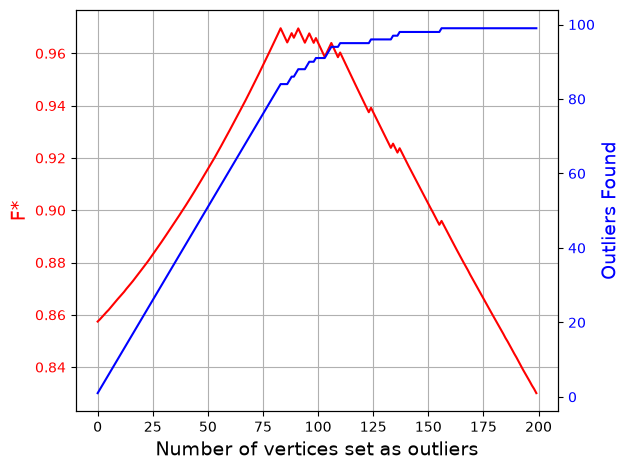

In [4]:
remove_order = np.argsort(refuse_scores)
n_to_remove = 200
outliers_found = np.empty(n_to_remove)
fs = np.empty(n_to_remove)
for i in range(n_to_remove):
    communities[remove_order[i]] = -1  # Set vertex with next lowest score as outlier
    outliers_found[i] = np.sum((communities == -1) & (ground_truth_communities == -1))
    fs[i] = fstar(communities, ground_truth_communities)

fig, ax1 = plt.subplots()
ax1.set_xlabel("Number of vertices set as outliers", fontsize=14)
ax1.set_ylabel("F*", color="red", fontsize=14)
ax1.plot(np.arange(n_to_remove), fs, color="red")
ax1.tick_params(axis="y", labelcolor="red")
plt.grid()

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.set_ylabel(
    "Outliers Found", color="blue", fontsize=14
)  # we already handled the x-label with ax1
ax2.plot(np.arange(n_to_remove), outliers_found, color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

fig.tight_layout()

These plots show that if we knew that we were looking for 100 vertices then we would do fairly well. Out of the 100 detected outliers, over 90 would be true outliers and we would have almost perfectly detected the communities (F* scores are between 0 and 1, so 0.95 is extremely high).

One way to try and choose a threshold for how many vertices to make outliers is to plot the refusal scores in sorted order and look for a kink or elbow in the plot.

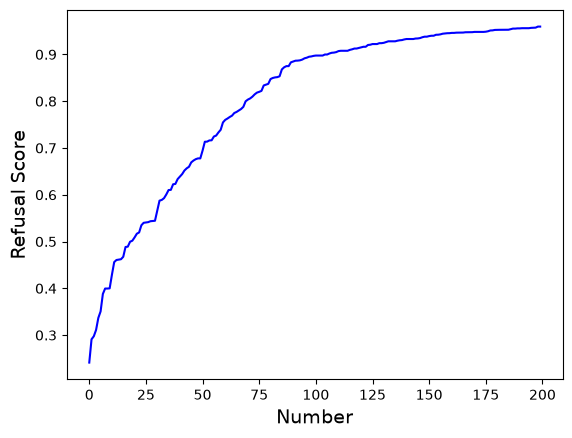

In [5]:
sorted_scores = refuse_scores[remove_order][:n_to_remove]
plt.plot(np.arange(n_to_remove), sorted_scores, color="blue")
plt.ylabel("Refusal Score", fontsize=14)
plt.xlabel("Number", fontsize=14);

Looking at this plot it would make sense to pick at least 50, and maybe up to 110 vertices to set as outliers.

## Benchmarking an algorithm with outliers

Let's suppose that our community detection algorithm sets 10% of vertices to outliers. Of course we encourage you to replace this naive algorithms with a better idea. We benchmark this algorithm use ABCD graphs and F*.

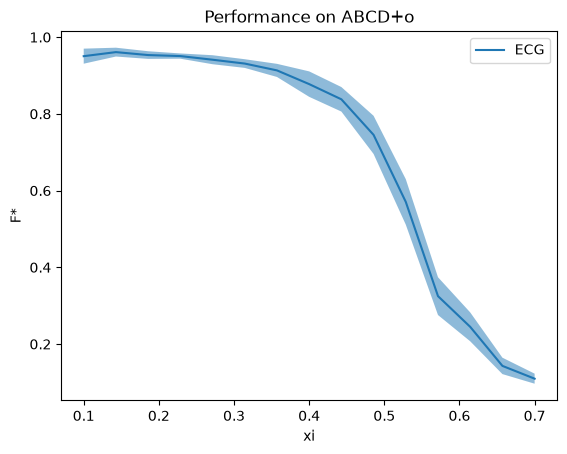

In [6]:
xis = np.linspace(0.1, 0.7, 15)
reps = 10
n = 1000
prop_outliers = 0.1

abcd = ABCD(n, outliers=prop_outliers, rng=np.random.default_rng(seed=42))
ecg = ECG(refuse_score=True, rng=np.random.default_rng(seed=42))
fs = np.empty((len(xis), reps))
for i, xi in enumerate(xis):
    for j in range(reps):
        abcd.xi = xi
        sample = abcd.sample()
        predict = ecg.fit_predict(sample.to_sparse(matrix=True))
        outliers = np.argsort(ecg.refuse_community_)[: int(n * prop_outliers)]
        predict[outliers] = -1
        fs[i, j] = fstar(predict, sample.community_array)

fs_mean = np.mean(fs, axis=1)
fs_std = np.std(fs, axis=1)
plt.plot(xis, fs_mean, label="ECG")
plt.fill_between(xis, fs_mean - fs_std, fs_mean + fs_std, alpha=0.5)
plt.title("Performance on ABCD+o")
plt.xlabel("xi")
plt.ylabel("F*")
plt.legend()

### References

ABCD+o
- [Bogumił Kamiński, Paweł Prałat, François Théberge. Artificial benchmark for community detection with outliers (ABCD+o). Applied Network Science 8 (2023) doi: 10.1007/s41109-023-00552-9](https://doi.org/10.1007/s41109-023-00552-9)

ECG
- [Valérie Poulin & François Théberge. Ensemble clustering for graphs: comparisons and applications. Applied Network Science 4:51 (2019) doi: 10.1007/s41109-019-0162-z](https://doi.org/10.1007/s41109-019-0162-z)
- Code: https://github.com/ftheberge/graph-partition-and-measures

F*
- [Ryan DeWolfe, Paweł Prałat, François Théberge. A Pragmatic Method for Comparing Clusterings with Overlaps and Outliers. arxiv preprint (2026) doi: 10.48550/arXiv.2602.14855](https://doi.org/10.48550/arXiv.2602.14855)
- Code: https://github.com/ryandewolfe33/fstar